In [2]:
# Cell 1: imports and environment check

import os
import random
import json
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
from openstl.models import SimVP_Model

try:
    from tqdm.auto import tqdm
except ImportError:
    tqdm = lambda x, **kwargs: x

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

device = "cuda" if torch.cuda.is_available() else "cpu"

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.2.1+cu121
CUDA available: True
device: cuda
GPU: NVIDIA GeForce GTX 1080 Ti


In [36]:
# Cell 2: configuration

z_path = "all_z.npy"

# Main setting: 10-to-10
input_len = 10
pred_len = 10

# For training windows
stride = 5

batch_size = 4
num_epochs = 30
learning_rate = 1e-3
weight_decay = 1e-5

# Simulation-level split
# all_z.shape = (50, 120, 128, 128)
train_sims = list(range(0, 35))
val_sims = list(range(35, 40))
test_sims = list(range(40, 50))

save_dir = f"simvp_zonly_{input_len}to{pred_len}_stride{stride}"
os.makedirs(save_dir, exist_ok=True)

best_model_path = os.path.join(save_dir, f"best_simvp_zonly_{input_len}to{pred_len}.pt")

print("z_path:", z_path)
print("input_len:", input_len)
print("pred_len:", pred_len)
print("stride:", stride)
print("batch_size:", batch_size)
print("num_epochs:", num_epochs)
print("learning_rate:", learning_rate)
print("train_sims:", train_sims)
print("val_sims:", val_sims)
print("test_sims:", test_sims)
print("save_dir:", save_dir)

z_path: all_z.npy
input_len: 10
pred_len: 10
stride: 5
batch_size: 4
num_epochs: 30
learning_rate: 0.001
train_sims: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34]
val_sims: [35, 36, 37, 38, 39]
test_sims: [40, 41, 42, 43, 44, 45, 46, 47, 48, 49]
save_dir: simvp_zonly_10to10_stride5


In [4]:
# Cell 3: load and inspect all_z.npy

z_raw = np.load(z_path, mmap_mode="r")

print("z shape:", z_raw.shape)
print("z dtype:", z_raw.dtype)
print("z min:", z_raw.min())
print("z max:", z_raw.max())

N, T, H, W = z_raw.shape

print("N:", N)
print("T:", T)
print("H:", H)
print("W:", W)

assert z_raw.shape == (50, 120, 128, 128), f"Unexpected shape: {z_raw.shape}"

z shape: (50, 120, 128, 128)
z dtype: float32
z min: 0.0062543545
z max: 196.61383
N: 50
T: 120
H: 128
W: 128


In [5]:
# Cell 4: save test_z.npy with required shape

test_z_raw = np.asarray(z_raw[test_sims], dtype=np.float32)

print("test_z_raw shape:", test_z_raw.shape)
assert test_z_raw.shape == (10, 120, 128, 128)

test_z_path = os.path.join(save_dir, "test_z.npy")
np.save(test_z_path, test_z_raw)

print("Saved:", test_z_path)
print("Required output shape:", test_z_raw.shape)

test_z_raw shape: (10, 120, 128, 128)
Saved: simvp_zonly_10to10_stride5/test_z.npy
Required output shape: (10, 120, 128, 128)


In [6]:
# Cell 5: normalization using training simulations only

z_train = np.asarray(z_raw[train_sims], dtype=np.float32)

z_min = float(z_train.min())
z_max = float(z_train.max())

print("train z_min:", z_min)
print("train z_max:", z_max)

z_all = np.asarray(z_raw, dtype=np.float32)
z_all = (z_all - z_min) / (z_max - z_min + 1e-8)

print("normalized shape:", z_all.shape)
print("normalized min:", z_all.min())
print("normalized max:", z_all.max())

norm_stats = {
    "z_min": z_min,
    "z_max": z_max,
    "normalization": "z_norm = (z - z_min_train) / (z_max_train - z_min_train)"
}

norm_stats_path = os.path.join(save_dir, "normalization_stats.json")
with open(norm_stats_path, "w") as f:
    json.dump(norm_stats, f, indent=2)

print("Saved:", norm_stats_path)

train z_min: 0.006254354491829872
train z_max: 196.61383056640625
normalized shape: (50, 120, 128, 128)
normalized min: 0.0
normalized max: 1.0
Saved: simvp_zonly_10to10_stride5/normalization_stats.json


In [7]:
# Cell 6: Dataset definition

class ZOnlyWindowDataset(Dataset):
    def __init__(self, z_array, sim_indices, input_len=10, pred_len=10, stride=5):
        """
        z_array: (N, T, H, W), normalized float32
        sim_indices: list of simulation indices
        returns:
            X: (input_len, 1, H, W)
            Y: (pred_len, 1, H, W)
        """
        self.z = z_array
        self.input_len = input_len
        self.pred_len = pred_len
        self.stride = stride
        self.indices = []

        _, T, _, _ = z_array.shape
        window_len = input_len + pred_len

        for sim_id in sim_indices:
            for t0 in range(0, T - window_len + 1, stride):
                self.indices.append((sim_id, t0))

        print(f"Created dataset: {len(self.indices)} samples from simulations {sim_indices}")

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        sim_id, t0 = self.indices[idx]

        x = self.z[sim_id, t0:t0+self.input_len]
        y = self.z[sim_id, t0+self.input_len:t0+self.input_len+self.pred_len]

        x = torch.from_numpy(x[:, None, :, :]).float()
        y = torch.from_numpy(y[:, None, :, :]).float()

        return x, y

In [8]:
# Cell 7: create DataLoaders

train_ds = ZOnlyWindowDataset(
    z_all,
    train_sims,
    input_len=input_len,
    pred_len=pred_len,
    stride=stride
)

val_ds = ZOnlyWindowDataset(
    z_all,
    val_sims,
    input_len=input_len,
    pred_len=pred_len,
    stride=stride
)

test_ds = ZOnlyWindowDataset(
    z_all,
    test_sims,
    input_len=input_len,
    pred_len=pred_len,
    stride=stride
)

train_loader = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print("train samples:", len(train_ds))
print("val samples:", len(val_ds))
print("test samples:", len(test_ds))

expected_train_per_sim = (T - input_len - pred_len) // stride + 1
print("expected windows per simulation:", expected_train_per_sim)

Created dataset: 735 samples from simulations [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34]
Created dataset: 105 samples from simulations [35, 36, 37, 38, 39]
Created dataset: 210 samples from simulations [40, 41, 42, 43, 44, 45, 46, 47, 48, 49]
train samples: 735
val samples: 105
test samples: 210
expected windows per simulation: 21


In [37]:
# Cell 8: create SimVP model

model = SimVP_Model(
    in_shape=(input_len, 1, H, W),
    hid_S=64,
    hid_T=256,
    N_S=4,
    N_T=8,
    model_type="gSTA",
).to(device)

criterion = nn.MSELoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=learning_rate,
    weight_decay=weight_decay
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=num_epochs
)

n_params = sum(p.numel() for p in model.parameters())
print(f"parameters: {n_params:,}")

X_test, Y_test = next(iter(train_loader))
X_test = X_test.to(device)

with torch.no_grad():
    pred_test = model(X_test)

print("input shape:", X_test.shape)
print("output shape:", pred_test.shape)
print("target shape:", Y_test.shape)

assert pred_test.shape == Y_test.to(device).shape

parameters: 18,603,009
input shape: torch.Size([4, 10, 1, 128, 128])
output shape: torch.Size([4, 10, 1, 128, 128])
target shape: torch.Size([4, 10, 1, 128, 128])


In [38]:
# Cell 9: training loop

train_losses = []
val_losses = []

best_val_loss = float("inf")
best_epoch = -1

for epoch in range(num_epochs):
    model.train()
    train_loss_sum = 0.0

    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1:03d}/{num_epochs} [train]")

    for X, Y in train_bar:
        X = X.to(device, non_blocking=True)
        Y = Y.to(device, non_blocking=True)

        pred = model(X)
        loss = criterion(pred, Y)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_loss_sum += loss.item() * X.size(0)
        train_bar.set_postfix(loss=f"{loss.item():.6f}")

    train_loss = train_loss_sum / len(train_loader.dataset)
    train_losses.append(train_loss)

    model.eval()
    val_loss_sum = 0.0

    val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1:03d}/{num_epochs} [val]")

    with torch.no_grad():
        for X, Y in val_bar:
            X = X.to(device, non_blocking=True)
            Y = Y.to(device, non_blocking=True)

            pred = model(X)
            loss = criterion(pred, Y)

            val_loss_sum += loss.item() * X.size(0)
            val_bar.set_postfix(loss=f"{loss.item():.6f}")

    val_loss = val_loss_sum / len(val_loader.dataset)
    val_losses.append(val_loss)

    scheduler.step()

    print(
        f"Epoch {epoch+1:03d}/{num_epochs} | "
        f"train MSE: {train_loss:.8f} | "
        f"val MSE: {val_loss:.8f} | "
        f"lr: {scheduler.get_last_lr()[0]:.6e}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch + 1

        torch.save(
            {
                "epoch": best_epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_loss": best_val_loss,
                "input_len": input_len,
                "pred_len": pred_len,
                "stride": stride,
                "z_min": z_min,
                "z_max": z_max,
            },
            best_model_path
        )

        print("Saved best model:", best_model_path)

print("Best epoch:", best_epoch)
print("Best val loss:", best_val_loss)

Epoch 001/30 [train]:   0%|          | 0/184 [00:00<?, ?it/s]

Epoch 001/30 [val]:   0%|          | 0/27 [00:00<?, ?it/s]

Epoch 001/30 | train MSE: 0.00952549 | val MSE: 0.00041460 | lr: 9.972609e-04
Saved best model: simvp_zonly_10to10_stride5/best_simvp_zonly_10to10.pt


Epoch 002/30 [train]:   0%|          | 0/184 [00:00<?, ?it/s]

Epoch 002/30 [val]:   0%|          | 0/27 [00:00<?, ?it/s]

...

Epoch 029/30 [val]:   0%|          | 0/27 [00:00<?, ?it/s]

Epoch 029/30 | train MSE: 0.00001151 | val MSE: 0.00002268 | lr: 2.739052e-06


Epoch 030/30 [train]:   0%|          | 0/184 [00:00<?, ?it/s]

Epoch 030/30 [val]:   0%|          | 0/27 [00:00<?, ?it/s]

Epoch 030/30 | train MSE: 0.00001169 | val MSE: 0.00002302 | lr: 0.000000e+00
Best epoch: 24
Best val loss: 2.1513662501266004e-05


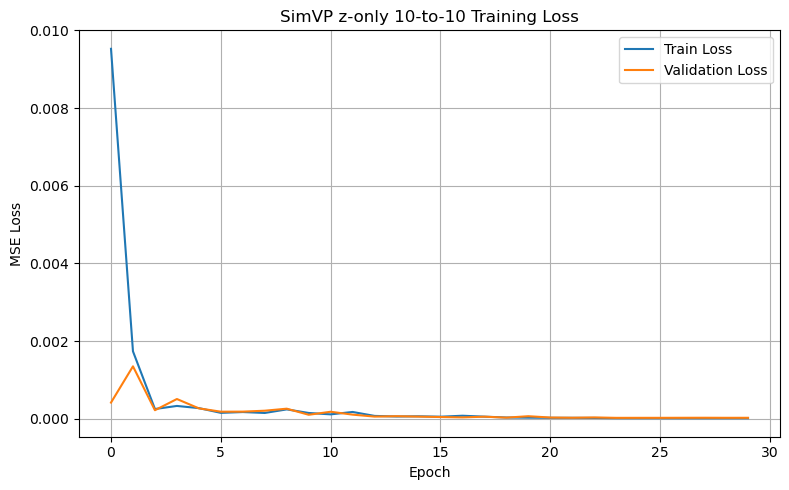

Saved: simvp_zonly_10to10_stride5/loss_curve.png


In [39]:
# Cell 10: plot loss curve

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title(f"SimVP z-only {input_len}-to-{pred_len} Training Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()

loss_fig_path = os.path.join(save_dir, "loss_curve.png")
plt.savefig(loss_fig_path, dpi=200)
plt.show()

np.save(os.path.join(save_dir, "train_losses.npy"), np.array(train_losses))
np.save(os.path.join(save_dir, "val_losses.npy"), np.array(val_losses))

print("Saved:", loss_fig_path)

In [40]:
# Cell 11: load best model

checkpoint = torch.load(best_model_path, map_location=device)

model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
model.eval()

print("Loaded best model from epoch:", checkpoint["epoch"])
print("Best val loss:", checkpoint["val_loss"])

Loaded best model from epoch: 24
Best val loss: 2.1513662501266004e-05


In [13]:
# Cell 12: short-term test evaluation with MSE MAE RMSE

def evaluate_loader(model, loader):
    model.eval()

    mse_sum = 0.0
    mae_sum = 0.0
    n_pixels = 0

    with torch.no_grad():
        for X, Y in tqdm(loader, desc="Testing SimVP"):
            X = X.to(device, non_blocking=True)
            Y = Y.to(device, non_blocking=True)

            pred = model(X)

            mse_sum += torch.sum((pred - Y) ** 2).item()
            mae_sum += torch.sum(torch.abs(pred - Y)).item()
            n_pixels += Y.numel()

    mse = mse_sum / n_pixels
    mae = mae_sum / n_pixels
    rmse = mse ** 0.5

    return mse, mae, rmse

test_mse, test_mae, test_rmse = evaluate_loader(model, test_loader)

print(f"SimVP Test MSE : {test_mse:.8f}")
print(f"SimVP Test MAE : {test_mae:.8f}")
print(f"SimVP Test RMSE: {test_rmse:.8f}")

Testing SimVP:   0%|          | 0/53 [00:00<?, ?it/s]

SimVP Test MSE : 0.00003057
SimVP Test MAE : 0.00429442
SimVP Test RMSE: 0.00552939


In [14]:
# Cell 13: linear extrapolation baseline for short-term windows

def linear_extrapolation_from_input(X, pred_len):
    """
    X: (B, input_len, 1, H, W)
    Uses pixel-wise linear regression over input frames.
    Returns:
        pred: (B, pred_len, 1, H, W)
    """
    B, Tin, C, H, W = X.shape

    t = torch.arange(Tin, device=X.device, dtype=X.dtype)
    t_mean = t.mean()
    t_centered = t - t_mean

    x_mean = X.mean(dim=1, keepdim=True)

    numerator = ((t_centered.view(1, Tin, 1, 1, 1)) * (X - x_mean)).sum(dim=1, keepdim=True)
    denominator = (t_centered ** 2).sum() + 1e-8

    slope = numerator / denominator
    intercept = x_mean - slope * t_mean

    future_t = torch.arange(Tin, Tin + pred_len, device=X.device, dtype=X.dtype)
    pred = intercept + slope * future_t.view(1, pred_len, 1, 1, 1)

    return pred


def evaluate_linear_baseline(loader):
    mse_sum = 0.0
    mae_sum = 0.0
    n_pixels = 0

    with torch.no_grad():
        for X, Y in tqdm(loader, desc="Linear extrapolation baseline"):
            X = X.to(device, non_blocking=True)
            Y = Y.to(device, non_blocking=True)

            pred = linear_extrapolation_from_input(X, pred_len=Y.shape[1])

            mse_sum += torch.sum((pred - Y) ** 2).item()
            mae_sum += torch.sum(torch.abs(pred - Y)).item()
            n_pixels += Y.numel()

    mse = mse_sum / n_pixels
    mae = mae_sum / n_pixels
    rmse = mse ** 0.5

    return mse, mae, rmse

base_mse, base_mae, base_rmse = evaluate_linear_baseline(test_loader)

print("Linear extrapolation baseline")
print(f"MSE : {base_mse:.8f}")
print(f"MAE : {base_mae:.8f}")
print(f"RMSE: {base_rmse:.8f}")

print()
print("SimVP improvement over linear baseline")
print(f"MSE improvement : {(base_mse - test_mse) / base_mse * 100:.2f}%")
print(f"MAE improvement : {(base_mae - test_mae) / base_mae * 100:.2f}%")
print(f"RMSE improvement: {(base_rmse - test_rmse) / base_rmse * 100:.2f}%")

Linear extrapolation baseline:   0%|          | 0/53 [00:00<?, ?it/s]

Linear extrapolation baseline
MSE : 0.00000297
MAE : 0.00088766
RMSE: 0.00172270

SimVP improvement over linear baseline
MSE improvement : -930.23%
MAE improvement : -383.79%
RMSE improvement: -220.97%


In [27]:
# Cell 14: Fourier-based spectral evaluation functions

import numpy as np

def compute_fft_power_spectrum(z2d, dx=1.0, use_window=True, remove_mean=True):
    """
    Compute shifted 2D Fourier power spectrum.

    z2d:
        2D terrain array, shape (H, W)

    returns:
        P: normalized 2D power spectrum, shape (H, W)
        KR: radial wavenumber grid
    """
    z = np.asarray(z2d, dtype=np.float32)

    if remove_mean:
        z = z - np.mean(z)

    H, W = z.shape

    if use_window:
        wy = np.hanning(H)
        wx = np.hanning(W)
        window = np.outer(wy, wx)
        z = z * window

    F = np.fft.fftshift(np.fft.fft2(z))
    P = np.abs(F) ** 2

    ky = np.fft.fftshift(np.fft.fftfreq(H, d=dx)) * 2.0 * np.pi
    kx = np.fft.fftshift(np.fft.fftfreq(W, d=dx)) * 2.0 * np.pi

    KX, KY = np.meshgrid(kx, ky)
    KR = np.sqrt(KX ** 2 + KY ** 2)

    return P, KR


def normalize_spectrum(P, low_freq_radius=2):
    """
    Normalize 2D power spectrum after removing DC and very-low-frequency components.
    """
    P = np.asarray(P, dtype=np.float64).copy()

    H, W = P.shape
    cy, cx = H // 2, W // 2

    yy, xx = np.indices((H, W))
    rr = np.sqrt((yy - cy) ** 2 + (xx - cx) ** 2)

    P[rr < low_freq_radius] = 0.0

    total = np.sum(P)

    if total <= 1e-12:
        return P * np.nan

    return P / total


def fourier_2d_spectrum_relative_l2_error(pred_frame, true_frame, dx=1.0, low_freq_radius=2):
    """
    Compare full normalized 2D Fourier power spectra.

    This is stricter than comparing only the dominant wavelength.
    """
    P_pred, _ = compute_fft_power_spectrum(pred_frame, dx=dx)
    P_true, _ = compute_fft_power_spectrum(true_frame, dx=dx)

    P_pred = normalize_spectrum(P_pred, low_freq_radius=low_freq_radius)
    P_true = normalize_spectrum(P_true, low_freq_radius=low_freq_radius)

    if not np.all(np.isfinite(P_pred)) or not np.all(np.isfinite(P_true)):
        return np.nan

    numerator = np.linalg.norm(P_pred - P_true)
    denominator = np.linalg.norm(P_true) + 1e-12

    return float(numerator / denominator)


def radial_power_spectrum(P, KR, num_bins=64, k_min=None, k_max=None):
    """
    Convert 2D Fourier power spectrum into radial average.
    """
    P = np.asarray(P, dtype=np.float64)
    KR = np.asarray(KR, dtype=np.float64)

    if k_min is None:
        k_min = KR[KR > 0].min()

    if k_max is None:
        k_max = KR.max()

    bins = np.linspace(k_min, k_max, num_bins + 1)
    radial = np.zeros(num_bins, dtype=np.float64)

    for i in range(num_bins):
        mask = (KR >= bins[i]) & (KR < bins[i + 1])
        if np.any(mask):
            radial[i] = np.mean(P[mask])

    total = np.sum(radial)

    if total > 1e-12:
        radial = radial / total
    else:
        radial[:] = np.nan

    k_centers = 0.5 * (bins[:-1] + bins[1:])

    return k_centers, radial


def radial_spectrum_relative_l2_error(pred_frame, true_frame, dx=1.0, num_bins=64, low_freq_radius=2):
    """
    Compare radially averaged Fourier power spectra.
    This ignores direction but compares wavelength distribution.
    """
    P_pred, KR = compute_fft_power_spectrum(pred_frame, dx=dx)
    P_true, _ = compute_fft_power_spectrum(true_frame, dx=dx)

    P_pred = normalize_spectrum(P_pred, low_freq_radius=low_freq_radius)
    P_true = normalize_spectrum(P_true, low_freq_radius=low_freq_radius)

    _, R_pred = radial_power_spectrum(P_pred, KR, num_bins=num_bins)
    _, R_true = radial_power_spectrum(P_true, KR, num_bins=num_bins)

    if not np.all(np.isfinite(R_pred)) or not np.all(np.isfinite(R_true)):
        return np.nan

    numerator = np.linalg.norm(R_pred - R_true)
    denominator = np.linalg.norm(R_true) + 1e-12

    return float(numerator / denominator)


def estimate_soft_valley_spacing_fft(z2d, dx=1.0, low_freq_radius=2, power_quantile=0.995):
    """
    Soft estimate of dominant wavelength.

    Instead of using only one argmax frequency bin, this computes
    a weighted average wavenumber over the strongest spectral region.
    """
    P, KR = compute_fft_power_spectrum(z2d, dx=dx)
    P = normalize_spectrum(P, low_freq_radius=low_freq_radius)

    if not np.all(np.isfinite(P)):
        return np.nan

    threshold = np.quantile(P[P > 0], power_quantile) if np.any(P > 0) else np.nan

    if not np.isfinite(threshold):
        return np.nan

    mask = P >= threshold

    weights = P[mask]
    k_values = KR[mask]

    valid = k_values > 1e-12

    if not np.any(valid):
        return np.nan

    weights = weights[valid]
    k_values = k_values[valid]

    k_soft = np.sum(weights * k_values) / (np.sum(weights) + 1e-12)

    if k_soft <= 1e-12:
        return np.nan

    lambda_soft = 2.0 * np.pi / k_soft

    return float(lambda_soft)


def soft_relative_valley_spacing_error(pred_frame, true_frame, dx=1.0):
    lambda_pred = estimate_soft_valley_spacing_fft(pred_frame, dx=dx)
    lambda_true = estimate_soft_valley_spacing_fft(true_frame, dx=dx)

    if not np.isfinite(lambda_pred) or not np.isfinite(lambda_true) or lambda_true <= 1e-12:
        return np.nan, lambda_pred, lambda_true

    rel_err = abs(lambda_pred - lambda_true) / lambda_true

    return float(rel_err), lambda_pred, lambda_true

In [16]:
# Cell 15: Fourier valley spacing evaluation on short-term test windows

def evaluate_fourier_spacing_on_loader(model, loader, max_batches=None, dx=1.0):
    model.eval()

    rel_errors = []
    lambda_preds = []
    lambda_trues = []

    with torch.no_grad():
        for batch_idx, (X, Y) in enumerate(tqdm(loader, desc="Fourier spacing evaluation")):
            X = X.to(device, non_blocking=True)
            Y = Y.to(device, non_blocking=True)

            pred = model(X)

            pred_np = pred.detach().cpu().numpy()
            true_np = Y.detach().cpu().numpy()

            B, Tout, _, H, W = pred_np.shape

            for b in range(B):
                for t in range(Tout):
                    pr = pred_np[b, t, 0]
                    gt = true_np[b, t, 0]

                    rel_err, lp, lt = relative_valley_spacing_error(pr, gt, dx=dx)

                    rel_errors.append(rel_err)
                    lambda_preds.append(lp)
                    lambda_trues.append(lt)

            if max_batches is not None and batch_idx + 1 >= max_batches:
                break

    rel_errors = np.array(rel_errors, dtype=np.float32)
    lambda_preds = np.array(lambda_preds, dtype=np.float32)
    lambda_trues = np.array(lambda_trues, dtype=np.float32)

    return rel_errors, lambda_preds, lambda_trues


rel_errors, lambda_preds, lambda_trues = evaluate_fourier_spacing_on_loader(
    model,
    test_loader,
    max_batches=None,
    dx=1.0
)

mean_rel_spacing_error = np.nanmean(rel_errors)
median_rel_spacing_error = np.nanmedian(rel_errors)

print(f"Mean relative valley spacing error   : {mean_rel_spacing_error:.6f}")
print(f"Median relative valley spacing error : {median_rel_spacing_error:.6f}")

np.save(os.path.join(save_dir, "shortterm_relative_valley_spacing_errors.npy"), rel_errors)
np.save(os.path.join(save_dir, "shortterm_lambda_preds.npy"), lambda_preds)
np.save(os.path.join(save_dir, "shortterm_lambda_trues.npy"), lambda_trues)

Fourier spacing evaluation:   0%|          | 0/53 [00:00<?, ?it/s]

Mean relative valley spacing error   : 0.000000
Median relative valley spacing error : 0.000000


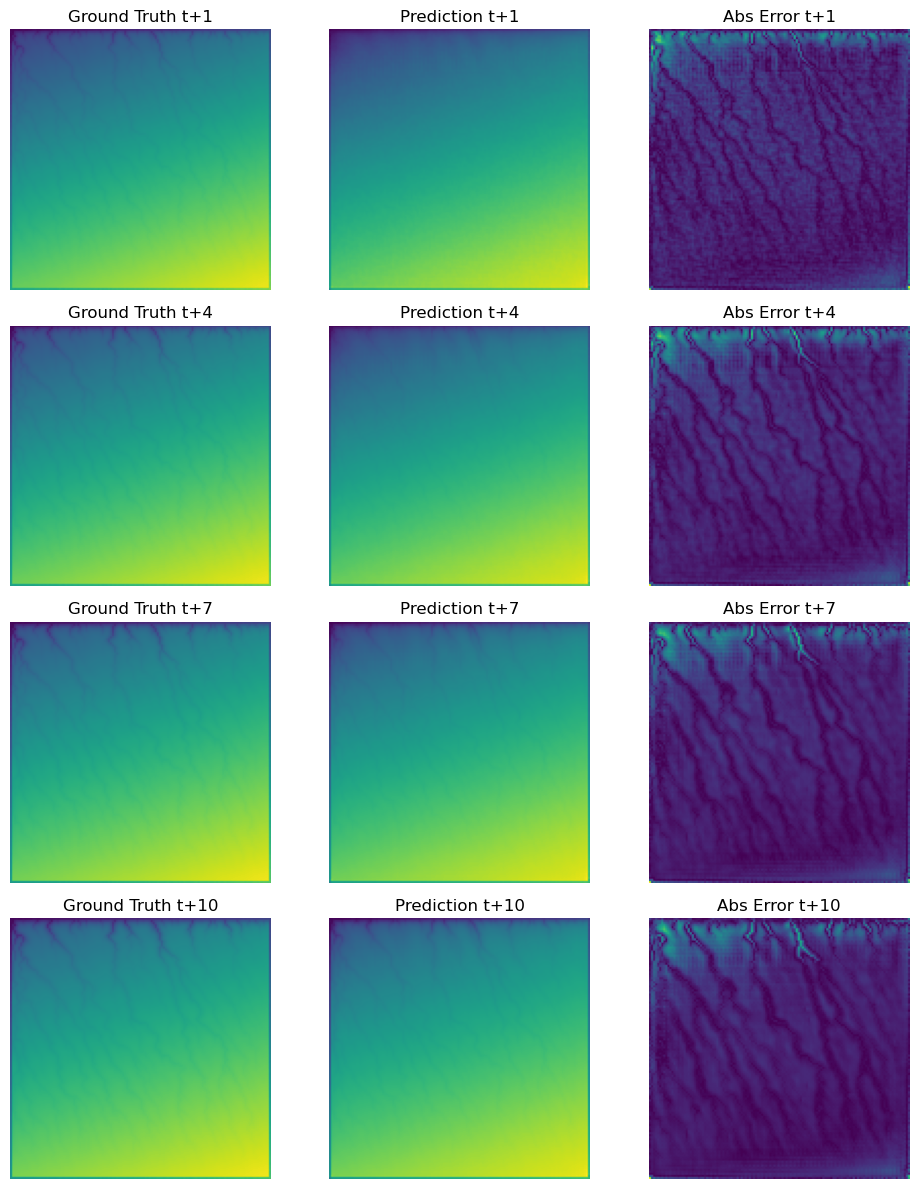

Saved: simvp_zonly_10to10_stride5/short_term_prediction.png


In [17]:
# Cell 16: visualize short-term prediction

X, Y = test_ds[0]

X_batch = X.unsqueeze(0).to(device)

with torch.no_grad():
    pred = model(X_batch).cpu().squeeze(0)

X = X.cpu()
Y = Y.cpu()

show_indices = [0, 3, 6, 9]

fig, axes = plt.subplots(len(show_indices), 3, figsize=(10, 3 * len(show_indices)))

for row, idx in enumerate(show_indices):
    gt = Y[idx, 0].numpy()
    pr = pred[idx, 0].numpy()
    err = np.abs(pr - gt)

    vmin = min(gt.min(), pr.min())
    vmax = max(gt.max(), pr.max())

    axes[row, 0].imshow(gt, vmin=vmin, vmax=vmax)
    axes[row, 0].set_title(f"Ground Truth t+{idx+1}")

    axes[row, 1].imshow(pr, vmin=vmin, vmax=vmax)
    axes[row, 1].set_title(f"Prediction t+{idx+1}")

    axes[row, 2].imshow(err)
    axes[row, 2].set_title(f"Abs Error t+{idx+1}")

    for col in range(3):
        axes[row, col].axis("off")

plt.tight_layout()

short_fig_path = os.path.join(save_dir, "short_term_prediction.png")
plt.savefig(short_fig_path, dpi=200)
plt.show()

print("Saved:", short_fig_path)

In [18]:
# Cell 17: autoregressive rollout for full 120-frame test trajectories

def rollout_full_trajectory_10to10(model, z_norm, sim_indices, input_len=10, pred_len=10):
    """
    For each test simulation:
        use ground-truth frames 0-9 as initial condition
        autoregressively predict frames 10-119

    returns:
        pred_full: (num_sims, 120, H, W), normalized
        true_full: (num_sims, 120, H, W), normalized
    """
    model.eval()

    pred_full_list = []
    true_full_list = []

    with torch.no_grad():
        for sim_id in tqdm(sim_indices, desc="Full rollout"):
            true_seq = z_norm[sim_id]  # (120,H,W)

            current = torch.from_numpy(true_seq[:input_len, None, :, :]).float()
            current = current.unsqueeze(0).to(device)  # (1,10,1,H,W)

            preds = [true_seq[:input_len]]

            frames_predicted = input_len

            while frames_predicted < T:
                pred_block = model(current)  # (1,10,1,H,W)

                pred_np = pred_block.detach().cpu().numpy()[0, :, 0]  # (10,H,W)

                remaining = T - frames_predicted
                use_len = min(pred_len, remaining)

                preds.append(pred_np[:use_len])

                frames_predicted += use_len

                # next input is the latest input_len predicted frames
                generated_so_far = np.concatenate(preds, axis=0)
                next_input_np = generated_so_far[-input_len:]

                current = torch.from_numpy(next_input_np[:, None, :, :]).float()
                current = current.unsqueeze(0).to(device)

            pred_seq = np.concatenate(preds, axis=0)

            assert pred_seq.shape == true_seq.shape

            pred_full_list.append(pred_seq)
            true_full_list.append(true_seq)

    pred_full = np.stack(pred_full_list, axis=0)
    true_full = np.stack(true_full_list, axis=0)

    return pred_full, true_full


pred_full_norm, true_full_norm = rollout_full_trajectory_10to10(
    model,
    z_all,
    test_sims,
    input_len=input_len,
    pred_len=pred_len
)

print("pred_full_norm shape:", pred_full_norm.shape)
print("true_full_norm shape:", true_full_norm.shape)

assert pred_full_norm.shape == (10, 120, 128, 128)
assert true_full_norm.shape == (10, 120, 128, 128)

Full rollout:   0%|          | 0/10 [00:00<?, ?it/s]

pred_full_norm shape: (10, 120, 128, 128)
true_full_norm shape: (10, 120, 128, 128)


In [19]:
# Cell 18: denormalize and save full rollout arrays

def denormalize(z_norm, z_min, z_max):
    return z_norm * (z_max - z_min + 1e-8) + z_min


pred_full = denormalize(pred_full_norm, z_min, z_max).astype(np.float32)
true_full = denormalize(true_full_norm, z_min, z_max).astype(np.float32)

print("pred_full shape:", pred_full.shape)
print("true_full shape:", true_full.shape)

assert pred_full.shape == (10, 120, 128, 128)
assert true_full.shape == (10, 120, 128, 128)

pred_full_path = os.path.join(save_dir, "simvp_pred_full_120.npy")
true_full_path = os.path.join(save_dir, "simvp_true_full_120.npy")

np.save(pred_full_path, pred_full)
np.save(true_full_path, true_full)

print("Saved:", pred_full_path)
print("Saved:", true_full_path)

pred_full shape: (10, 120, 128, 128)
true_full shape: (10, 120, 128, 128)
Saved: simvp_zonly_10to10_stride5/simvp_pred_full_120.npy
Saved: simvp_zonly_10to10_stride5/simvp_true_full_120.npy


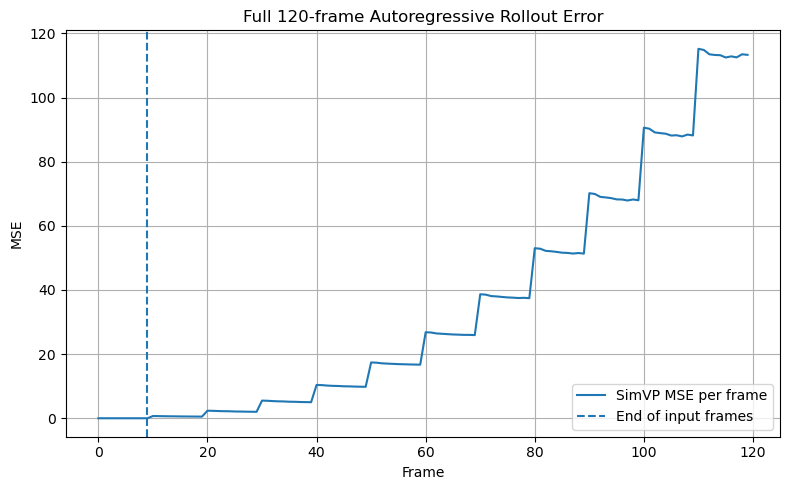

Saved: simvp_zonly_10to10_stride5/full_rollout_mse_per_frame.png
Mean MSE frames 10-119: 38.37321
Mean MAE frames 10-119: 3.96105


In [20]:
# Cell 19: full-rollout MSE over time

mse_per_frame = np.mean((pred_full - true_full) ** 2, axis=(0, 2, 3))
mae_per_frame = np.mean(np.abs(pred_full - true_full), axis=(0, 2, 3))

# Because frames 0-9 are given as input, their error should be zero.
frames = np.arange(T)

plt.figure(figsize=(8, 5))
plt.plot(frames, mse_per_frame, label="SimVP MSE per frame")
plt.axvline(input_len - 1, linestyle="--", label="End of input frames")
plt.xlabel("Frame")
plt.ylabel("MSE")
plt.title("Full 120-frame Autoregressive Rollout Error")
plt.legend()
plt.grid(True)
plt.tight_layout()

mse_fig_path = os.path.join(save_dir, "full_rollout_mse_per_frame.png")
plt.savefig(mse_fig_path, dpi=200)
plt.show()

np.save(os.path.join(save_dir, "full_rollout_mse_per_frame.npy"), mse_per_frame)
np.save(os.path.join(save_dir, "full_rollout_mae_per_frame.npy"), mae_per_frame)

print("Saved:", mse_fig_path)
print("Mean MSE frames 10-119:", mse_per_frame[input_len:].mean())
print("Mean MAE frames 10-119:", mae_per_frame[input_len:].mean())

In [21]:
# Cell 20: linear extrapolation baseline for full 120-frame trajectories

def linear_extrapolation_full_from_frames_0_to_9(z_seq, fit_len=10):
    """
    z_seq: (120,H,W), original scale or normalized scale
    Uses frames 0-9 to fit pixel-wise linear trend.
    Returns:
        pred_seq: (120,H,W)
    """
    T, H, W = z_seq.shape

    t = np.arange(fit_len, dtype=np.float32)
    t_mean = t.mean()
    t_centered = t - t_mean

    x = z_seq[:fit_len].astype(np.float32)
    x_mean = x.mean(axis=0, keepdims=True)

    numerator = np.sum(t_centered[:, None, None] * (x - x_mean), axis=0)
    denominator = np.sum(t_centered ** 2) + 1e-8

    slope = numerator / denominator
    intercept = x_mean[0] - slope * t_mean

    all_t = np.arange(T, dtype=np.float32)
    pred_seq = intercept[None, :, :] + slope[None, :, :] * all_t[:, None, None]

    # Keep frames 0-9 exactly equal to the observed input for fair rollout-style comparison
    pred_seq[:fit_len] = z_seq[:fit_len]

    return pred_seq.astype(np.float32)


baseline_full = []

for sim_id in tqdm(test_sims, desc="Full linear baseline"):
    seq = np.asarray(z_raw[sim_id], dtype=np.float32)
    pred_seq = linear_extrapolation_full_from_frames_0_to_9(seq, fit_len=10)
    baseline_full.append(pred_seq)

baseline_full = np.stack(baseline_full, axis=0)

print("baseline_full shape:", baseline_full.shape)
assert baseline_full.shape == (10, 120, 128, 128)

baseline_full_path = os.path.join(save_dir, "linear_baseline_full_120.npy")
np.save(baseline_full_path, baseline_full)

print("Saved:", baseline_full_path)

Full linear baseline:   0%|          | 0/10 [00:00<?, ?it/s]

baseline_full shape: (10, 120, 128, 128)
Saved: simvp_zonly_10to10_stride5/linear_baseline_full_120.npy


Full rollout, frames 10-119
SimVP MSE           : 38.37321091
Linear baseline MSE : 232.76324463
MSE improvement     : 83.51%

SimVP MAE           : 3.96105003
Linear baseline MAE : 7.32043552
MAE improvement     : 45.89%


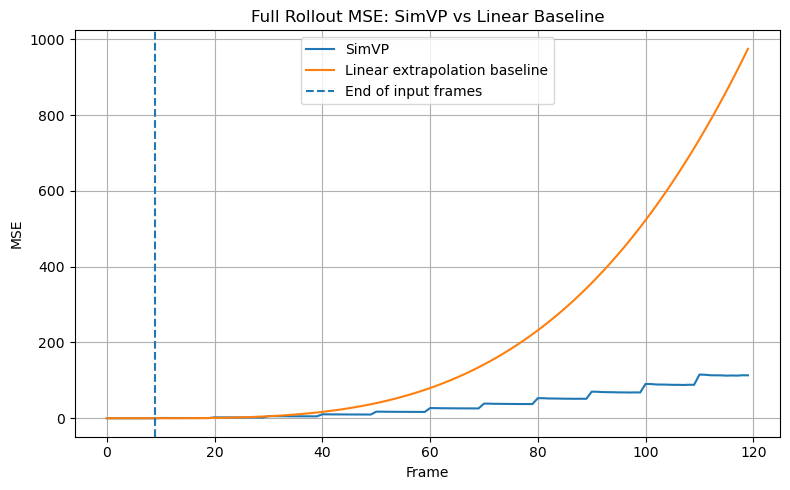

Saved: simvp_zonly_10to10_stride5/full_rollout_mse_simvp_vs_linear.png


In [22]:
# Cell 21: compare SimVP with linear extrapolation baseline on full rollout

baseline_mse_per_frame = np.mean((baseline_full - true_full) ** 2, axis=(0, 2, 3))
baseline_mae_per_frame = np.mean(np.abs(baseline_full - true_full), axis=(0, 2, 3))

simvp_future_mse = mse_per_frame[input_len:].mean()
base_future_mse = baseline_mse_per_frame[input_len:].mean()

simvp_future_mae = mae_per_frame[input_len:].mean()
base_future_mae = baseline_mae_per_frame[input_len:].mean()

print("Full rollout, frames 10-119")
print(f"SimVP MSE           : {simvp_future_mse:.8f}")
print(f"Linear baseline MSE : {base_future_mse:.8f}")
print(f"MSE improvement     : {(base_future_mse - simvp_future_mse) / base_future_mse * 100:.2f}%")
print()
print(f"SimVP MAE           : {simvp_future_mae:.8f}")
print(f"Linear baseline MAE : {base_future_mae:.8f}")
print(f"MAE improvement     : {(base_future_mae - simvp_future_mae) / base_future_mae * 100:.2f}%")

plt.figure(figsize=(8, 5))
plt.plot(frames, mse_per_frame, label="SimVP")
plt.plot(frames, baseline_mse_per_frame, label="Linear extrapolation baseline")
plt.axvline(input_len - 1, linestyle="--", label="End of input frames")
plt.xlabel("Frame")
plt.ylabel("MSE")
plt.title("Full Rollout MSE: SimVP vs Linear Baseline")
plt.legend()
plt.grid(True)
plt.tight_layout()

compare_fig_path = os.path.join(save_dir, "full_rollout_mse_simvp_vs_linear.png")
plt.savefig(compare_fig_path, dpi=200)
plt.show()

np.save(os.path.join(save_dir, "linear_baseline_mse_per_frame.npy"), baseline_mse_per_frame)
np.save(os.path.join(save_dir, "linear_baseline_mae_per_frame.npy"), baseline_mae_per_frame)

print("Saved:", compare_fig_path)

In [28]:
# Cell 22: Fourier spectrum evaluation on full 120-frame rollout

simvp_soft_spacing_error_by_frame = []
base_soft_spacing_error_by_frame = []

simvp_2d_spectrum_error_by_frame = []
base_2d_spectrum_error_by_frame = []

simvp_radial_spectrum_error_by_frame = []
base_radial_spectrum_error_by_frame = []

simvp_soft_lambda_by_frame = []
base_soft_lambda_by_frame = []
true_soft_lambda_by_frame = []

for t in tqdm(range(T), desc="Fourier spectral evaluation over full trajectory"):
    simvp_soft_errs_t = []
    base_soft_errs_t = []

    simvp_2d_errs_t = []
    base_2d_errs_t = []

    simvp_radial_errs_t = []
    base_radial_errs_t = []

    simvp_lambdas_t = []
    base_lambdas_t = []
    true_lambdas_t = []

    for i in range(len(test_sims)):
        true_frame = true_full[i, t]
        simvp_frame = pred_full[i, t]
        base_frame = baseline_full[i, t]

        # 1. Soft valley spacing error
        simvp_soft_rel, simvp_lambda, true_lambda = soft_relative_valley_spacing_error(
            simvp_frame,
            true_frame,
            dx=1.0
        )

        base_soft_rel, base_lambda, _ = soft_relative_valley_spacing_error(
            base_frame,
            true_frame,
            dx=1.0
        )

        # 2. Full 2D Fourier spectrum error
        simvp_2d_err = fourier_2d_spectrum_relative_l2_error(
            simvp_frame,
            true_frame,
            dx=1.0,
            low_freq_radius=2
        )

        base_2d_err = fourier_2d_spectrum_relative_l2_error(
            base_frame,
            true_frame,
            dx=1.0,
            low_freq_radius=2
        )

        # 3. Radial Fourier spectrum error
        simvp_radial_err = radial_spectrum_relative_l2_error(
            simvp_frame,
            true_frame,
            dx=1.0,
            num_bins=64,
            low_freq_radius=2
        )

        base_radial_err = radial_spectrum_relative_l2_error(
            base_frame,
            true_frame,
            dx=1.0,
            num_bins=64,
            low_freq_radius=2
        )

        simvp_soft_errs_t.append(simvp_soft_rel)
        base_soft_errs_t.append(base_soft_rel)

        simvp_2d_errs_t.append(simvp_2d_err)
        base_2d_errs_t.append(base_2d_err)

        simvp_radial_errs_t.append(simvp_radial_err)
        base_radial_errs_t.append(base_radial_err)

        simvp_lambdas_t.append(simvp_lambda)
        base_lambdas_t.append(base_lambda)
        true_lambdas_t.append(true_lambda)

    simvp_soft_spacing_error_by_frame.append(np.nanmean(simvp_soft_errs_t))
    base_soft_spacing_error_by_frame.append(np.nanmean(base_soft_errs_t))

    simvp_2d_spectrum_error_by_frame.append(np.nanmean(simvp_2d_errs_t))
    base_2d_spectrum_error_by_frame.append(np.nanmean(base_2d_errs_t))

    simvp_radial_spectrum_error_by_frame.append(np.nanmean(simvp_radial_errs_t))
    base_radial_spectrum_error_by_frame.append(np.nanmean(base_radial_errs_t))

    simvp_soft_lambda_by_frame.append(np.nanmean(simvp_lambdas_t))
    base_soft_lambda_by_frame.append(np.nanmean(base_lambdas_t))
    true_soft_lambda_by_frame.append(np.nanmean(true_lambdas_t))

simvp_soft_spacing_error_by_frame = np.array(simvp_soft_spacing_error_by_frame, dtype=np.float32)
base_soft_spacing_error_by_frame = np.array(base_soft_spacing_error_by_frame, dtype=np.float32)

simvp_2d_spectrum_error_by_frame = np.array(simvp_2d_spectrum_error_by_frame, dtype=np.float32)
base_2d_spectrum_error_by_frame = np.array(base_2d_spectrum_error_by_frame, dtype=np.float32)

simvp_radial_spectrum_error_by_frame = np.array(simvp_radial_spectrum_error_by_frame, dtype=np.float32)
base_radial_spectrum_error_by_frame = np.array(base_radial_spectrum_error_by_frame, dtype=np.float32)

simvp_soft_lambda_by_frame = np.array(simvp_soft_lambda_by_frame, dtype=np.float32)
base_soft_lambda_by_frame = np.array(base_soft_lambda_by_frame, dtype=np.float32)
true_soft_lambda_by_frame = np.array(true_soft_lambda_by_frame, dtype=np.float32)

print("Mean Fourier metrics, frames 10-119")
print()
print("Soft relative valley spacing error")
print(f"SimVP          : {np.nanmean(simvp_soft_spacing_error_by_frame[input_len:]):.6f}")
print(f"Linear baseline: {np.nanmean(base_soft_spacing_error_by_frame[input_len:]):.6f}")
print()
print("2D Fourier spectrum relative L2 error")
print(f"SimVP          : {np.nanmean(simvp_2d_spectrum_error_by_frame[input_len:]):.6f}")
print(f"Linear baseline: {np.nanmean(base_2d_spectrum_error_by_frame[input_len:]):.6f}")
print()
print("Radial Fourier spectrum relative L2 error")
print(f"SimVP          : {np.nanmean(simvp_radial_spectrum_error_by_frame[input_len:]):.6f}")
print(f"Linear baseline: {np.nanmean(base_radial_spectrum_error_by_frame[input_len:]):.6f}")

np.save(os.path.join(save_dir, "full_simvp_soft_relative_valley_spacing_error_by_frame.npy"), simvp_soft_spacing_error_by_frame)
np.save(os.path.join(save_dir, "full_linear_soft_relative_valley_spacing_error_by_frame.npy"), base_soft_spacing_error_by_frame)

np.save(os.path.join(save_dir, "full_simvp_2d_fourier_spectrum_error_by_frame.npy"), simvp_2d_spectrum_error_by_frame)
np.save(os.path.join(save_dir, "full_linear_2d_fourier_spectrum_error_by_frame.npy"), base_2d_spectrum_error_by_frame)

np.save(os.path.join(save_dir, "full_simvp_radial_fourier_spectrum_error_by_frame.npy"), simvp_radial_spectrum_error_by_frame)
np.save(os.path.join(save_dir, "full_linear_radial_fourier_spectrum_error_by_frame.npy"), base_radial_spectrum_error_by_frame)

np.save(os.path.join(save_dir, "full_simvp_soft_lambda_by_frame.npy"), simvp_soft_lambda_by_frame)
np.save(os.path.join(save_dir, "full_linear_soft_lambda_by_frame.npy"), base_soft_lambda_by_frame)
np.save(os.path.join(save_dir, "full_true_soft_lambda_by_frame.npy"), true_soft_lambda_by_frame)

Fourier spectral evaluation over full trajectory:   0%|          | 0/120 [00:00<?, ?it/s]

Mean Fourier metrics, frames 10-119

Soft relative valley spacing error
SimVP          : 0.210675
Linear baseline: 0.223593

2D Fourier spectrum relative L2 error
SimVP          : 0.614234
Linear baseline: 0.479790

Radial Fourier spectrum relative L2 error
SimVP          : 0.322622
Linear baseline: 0.334530


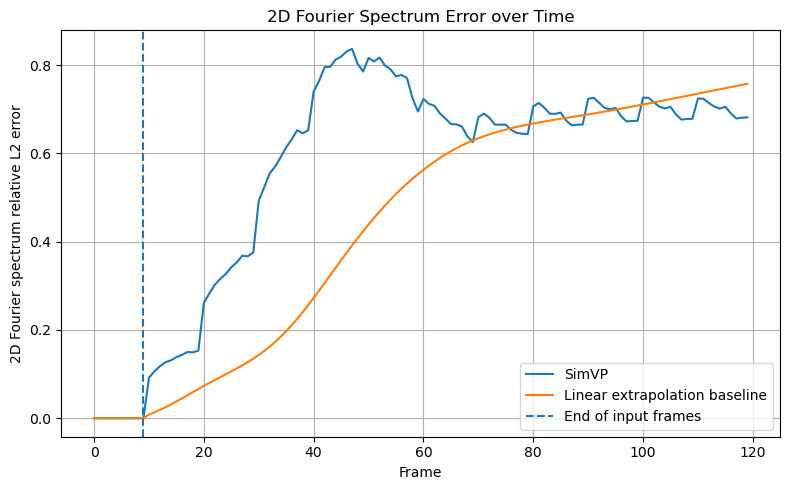

Saved: simvp_zonly_10to10_stride5/2d_fourier_spectrum_error_over_time.png


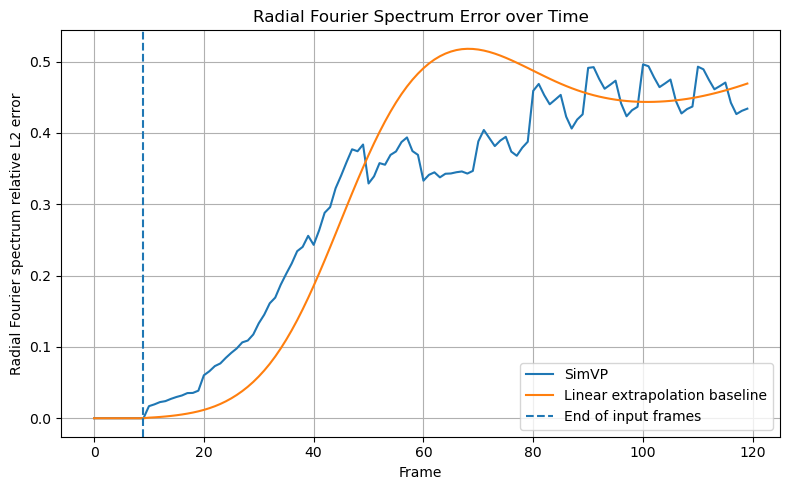

Saved: simvp_zonly_10to10_stride5/radial_fourier_spectrum_error_over_time.png


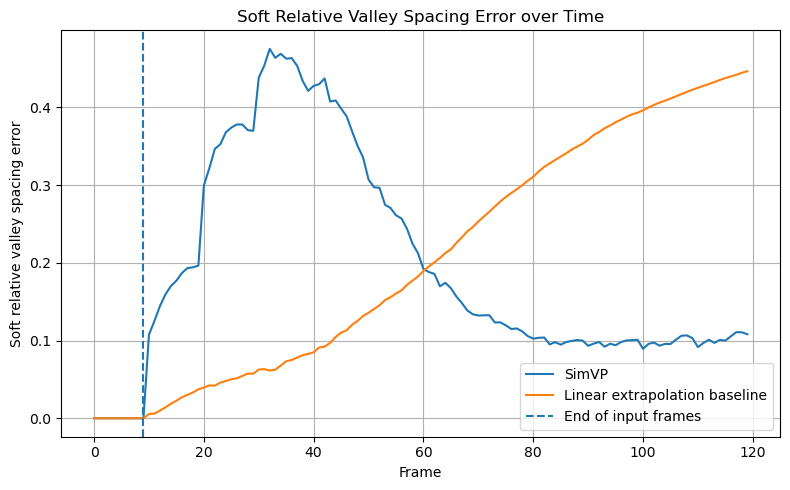

Saved: simvp_zonly_10to10_stride5/soft_relative_valley_spacing_error_over_time.png


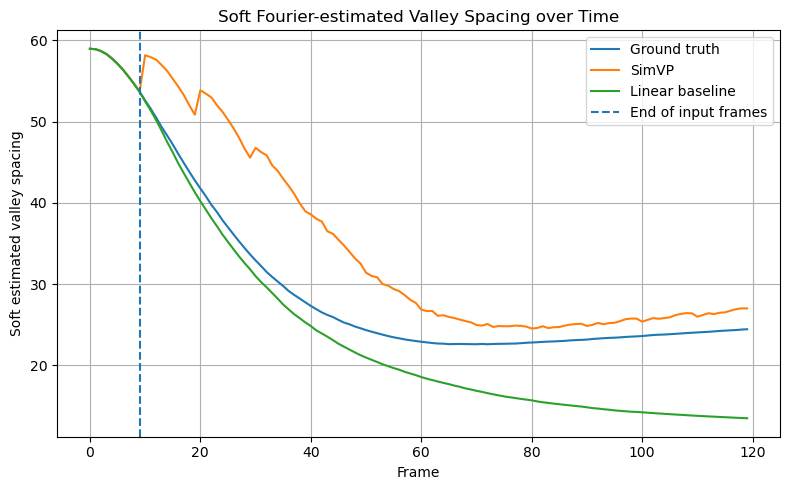

Saved: simvp_zonly_10to10_stride5/soft_fourier_valley_spacing_over_time.png


In [29]:
# Cell 23: plot Fourier spectral metrics

plt.figure(figsize=(8, 5))
plt.plot(frames, simvp_2d_spectrum_error_by_frame, label="SimVP")
plt.plot(frames, base_2d_spectrum_error_by_frame, label="Linear extrapolation baseline")
plt.axvline(input_len - 1, linestyle="--", label="End of input frames")
plt.xlabel("Frame")
plt.ylabel("2D Fourier spectrum relative L2 error")
plt.title("2D Fourier Spectrum Error over Time")
plt.legend()
plt.grid(True)
plt.tight_layout()

fig_path = os.path.join(save_dir, "2d_fourier_spectrum_error_over_time.png")
plt.savefig(fig_path, dpi=200)
plt.show()

print("Saved:", fig_path)


plt.figure(figsize=(8, 5))
plt.plot(frames, simvp_radial_spectrum_error_by_frame, label="SimVP")
plt.plot(frames, base_radial_spectrum_error_by_frame, label="Linear extrapolation baseline")
plt.axvline(input_len - 1, linestyle="--", label="End of input frames")
plt.xlabel("Frame")
plt.ylabel("Radial Fourier spectrum relative L2 error")
plt.title("Radial Fourier Spectrum Error over Time")
plt.legend()
plt.grid(True)
plt.tight_layout()

fig_path = os.path.join(save_dir, "radial_fourier_spectrum_error_over_time.png")
plt.savefig(fig_path, dpi=200)
plt.show()

print("Saved:", fig_path)


plt.figure(figsize=(8, 5))
plt.plot(frames, simvp_soft_spacing_error_by_frame, label="SimVP")
plt.plot(frames, base_soft_spacing_error_by_frame, label="Linear extrapolation baseline")
plt.axvline(input_len - 1, linestyle="--", label="End of input frames")
plt.xlabel("Frame")
plt.ylabel("Soft relative valley spacing error")
plt.title("Soft Relative Valley Spacing Error over Time")
plt.legend()
plt.grid(True)
plt.tight_layout()

fig_path = os.path.join(save_dir, "soft_relative_valley_spacing_error_over_time.png")
plt.savefig(fig_path, dpi=200)
plt.show()

print("Saved:", fig_path)


plt.figure(figsize=(8, 5))
plt.plot(frames, true_soft_lambda_by_frame, label="Ground truth")
plt.plot(frames, simvp_soft_lambda_by_frame, label="SimVP")
plt.plot(frames, base_soft_lambda_by_frame, label="Linear baseline")
plt.axvline(input_len - 1, linestyle="--", label="End of input frames")
plt.xlabel("Frame")
plt.ylabel("Soft estimated valley spacing")
plt.title("Soft Fourier-estimated Valley Spacing over Time")
plt.legend()
plt.grid(True)
plt.tight_layout()

fig_path = os.path.join(save_dir, "soft_fourier_valley_spacing_over_time.png")
plt.savefig(fig_path, dpi=200)
plt.show()

print("Saved:", fig_path)

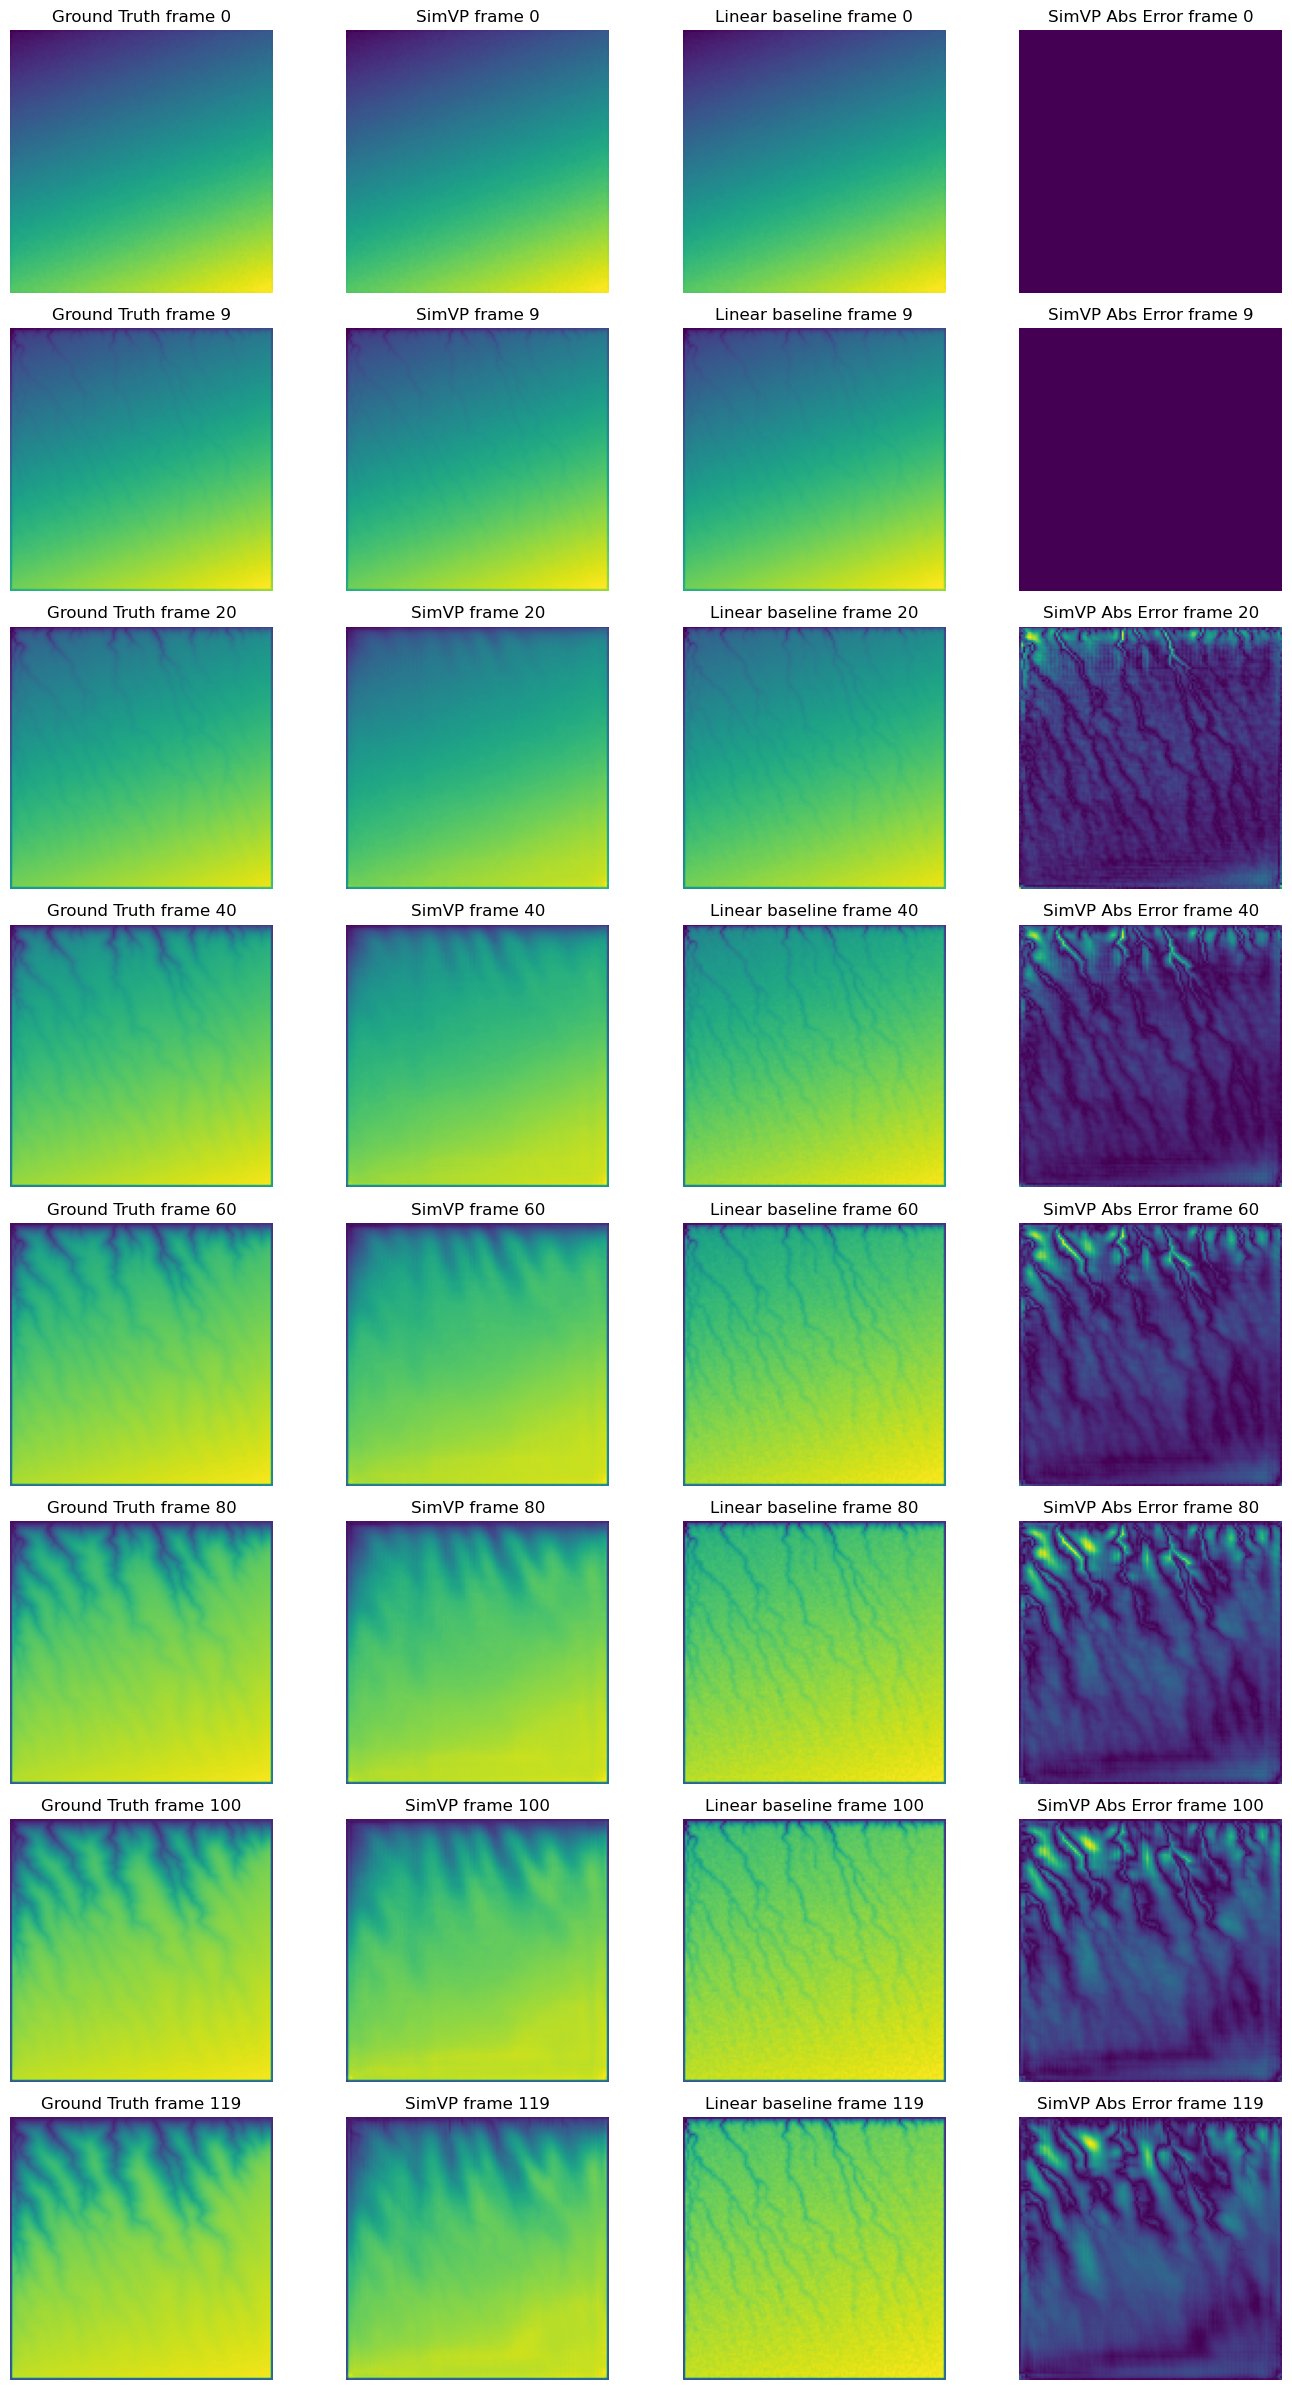

Saved: simvp_zonly_10to10_stride5/full_rollout_visualization.png


In [25]:
# Cell 24: visualize full rollout prediction

sim_idx_in_test = 0

show_frames = [0, 9, 20, 40, 60, 80, 100, 119]

fig, axes = plt.subplots(len(show_frames), 4, figsize=(14, 3 * len(show_frames)))

for row, frame in enumerate(show_frames):
    gt = true_full[sim_idx_in_test, frame]
    pr = pred_full[sim_idx_in_test, frame]
    bl = baseline_full[sim_idx_in_test, frame]
    err = np.abs(pr - gt)

    vmin = min(gt.min(), pr.min(), bl.min())
    vmax = max(gt.max(), pr.max(), bl.max())

    axes[row, 0].imshow(gt, vmin=vmin, vmax=vmax)
    axes[row, 0].set_title(f"Ground Truth frame {frame}")

    axes[row, 1].imshow(pr, vmin=vmin, vmax=vmax)
    axes[row, 1].set_title(f"SimVP frame {frame}")

    axes[row, 2].imshow(bl, vmin=vmin, vmax=vmax)
    axes[row, 2].set_title(f"Linear baseline frame {frame}")

    axes[row, 3].imshow(err)
    axes[row, 3].set_title(f"SimVP Abs Error frame {frame}")

    for col in range(4):
        axes[row, col].axis("off")

plt.tight_layout()

full_vis_path = os.path.join(save_dir, "full_rollout_visualization.png")
plt.savefig(full_vis_path, dpi=200)
plt.show()

print("Saved:", full_vis_path)

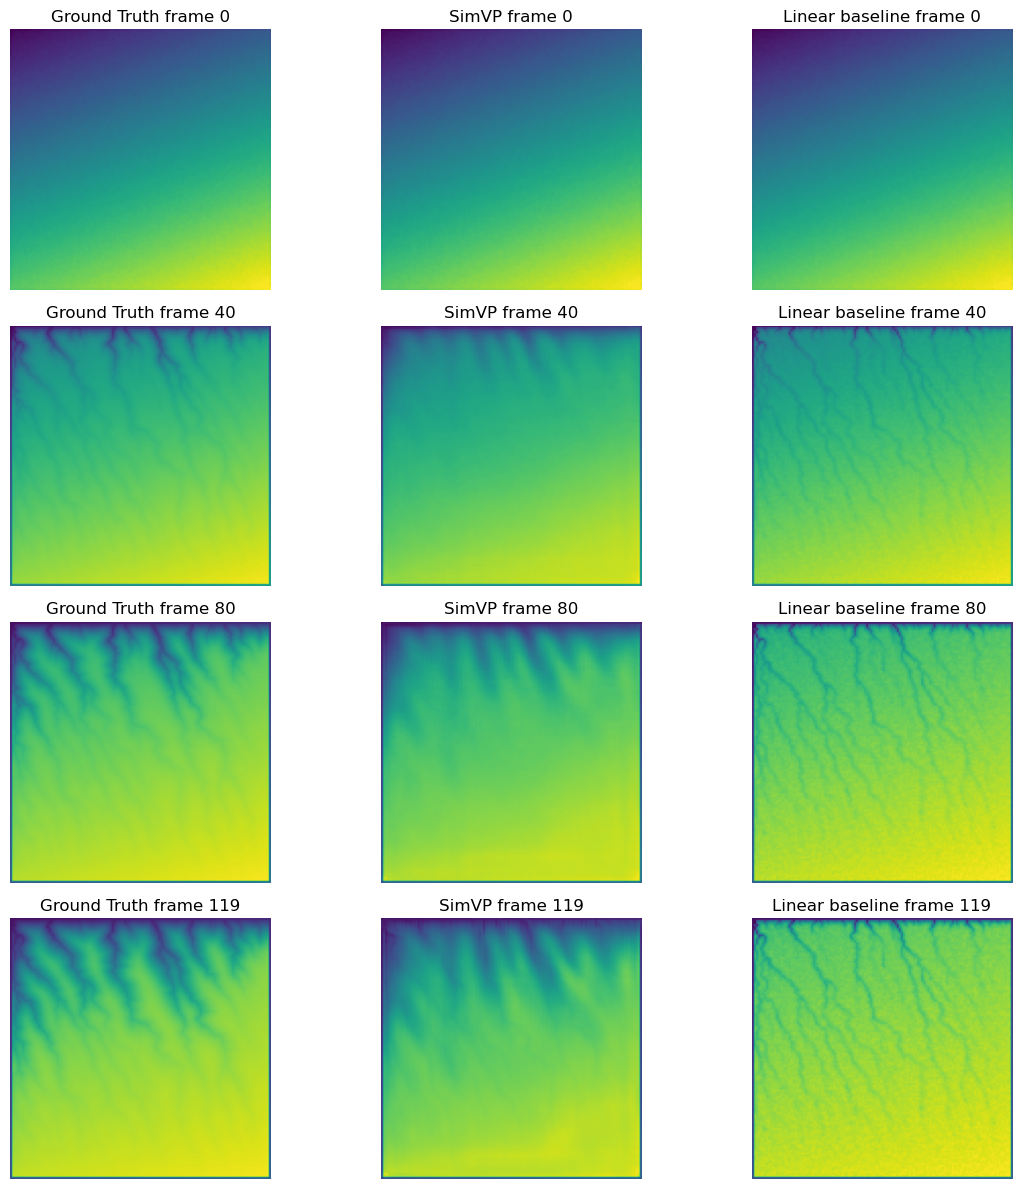

Saved: simvp_zonly_10to10_stride5/full_rollout_visualization_4frames.png


In [30]:
# Cell 24: visualize full rollout prediction (4 selected frames, no error column)

sim_idx_in_test = 0

show_frames = [0, 40, 80, 119]

fig, axes = plt.subplots(len(show_frames), 3, figsize=(12, 3 * len(show_frames)))

for row, frame in enumerate(show_frames):
    gt = true_full[sim_idx_in_test, frame]
    pr = pred_full[sim_idx_in_test, frame]
    bl = baseline_full[sim_idx_in_test, frame]

    vmin = min(gt.min(), pr.min(), bl.min())
    vmax = max(gt.max(), pr.max(), bl.max())

    axes[row, 0].imshow(gt, vmin=vmin, vmax=vmax)
    axes[row, 0].set_title(f"Ground Truth frame {frame}")

    axes[row, 1].imshow(pr, vmin=vmin, vmax=vmax)
    axes[row, 1].set_title(f"SimVP frame {frame}")

    axes[row, 2].imshow(bl, vmin=vmin, vmax=vmax)
    axes[row, 2].set_title(f"Linear baseline frame {frame}")

    for col in range(3):
        axes[row, col].axis("off")

plt.tight_layout()

full_vis_path = os.path.join(save_dir, "full_rollout_visualization_4frames.png")
plt.savefig(full_vis_path, dpi=200)
plt.show()

print("Saved:", full_vis_path)